In [31]:
import pandas as pd

df = pd.read_csv("Life_Expectancy_Data.csv")
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

In [33]:
df.shape

(2938, 22)

In [34]:
df.dtypes

Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [35]:
#per column isnull sum printing
for i in df.columns:
    print(i,df[i].isnull().sum())

Country 0
Year 0
Status 0
Life expectancy  10
Adult Mortality 10
infant deaths 0
Alcohol 194
percentage expenditure 0
Hepatitis B 553
Measles  0
 BMI  34
under-five deaths  0
Polio 19
Total expenditure 226
Diphtheria  19
 HIV/AIDS 0
GDP 448
Population 652
 thinness  1-19 years 34
 thinness 5-9 years 34
Income composition of resources 167
Schooling 163


In [36]:
df.columns = df.columns.str.strip()

In [37]:
#renaming column names
df.rename(columns={
    "Life expectancy": "Life_expectancy",
    "Adult Mortality": "Adult_Mortality",
    "infant deaths": "Infant_deaths",
    "percentage expenditure": "Percentage_expenditure",
    "Hepatitis B": "Hepatitis_B",
    "under-five deaths": "Under_five_deaths",
    "Total expenditure": "Total_expenditure",
    "HIV/AIDS": "HIV_AIDS",
    "thinness  1-19 years": "Thinness_1_19_years",
    "thinness 5-9 years": "Thinness_5_9_years",
    "Income composition of resources": "Income_composition_resources"
}, inplace=True)

In [38]:
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality',
       'Infant_deaths', 'Alcohol', 'Percentage_expenditure', 'Hepatitis_B',
       'Measles', 'BMI', 'Under_five_deaths', 'Polio', 'Total_expenditure',
       'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'Thinness_1_19_years',
       'Thinness_5_9_years', 'Income_composition_resources', 'Schooling'],
      dtype='object')


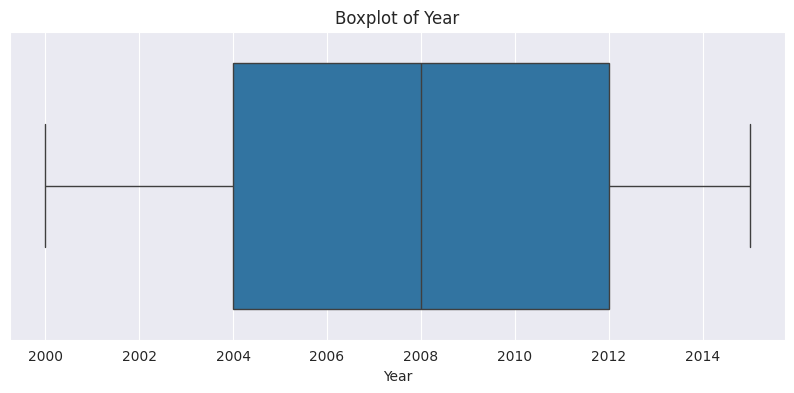

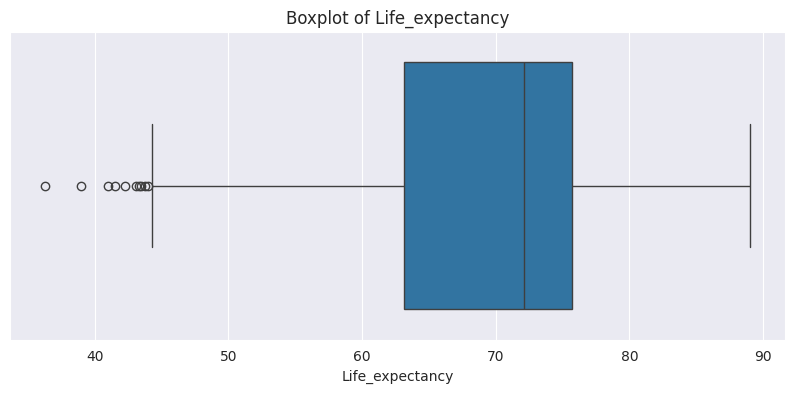

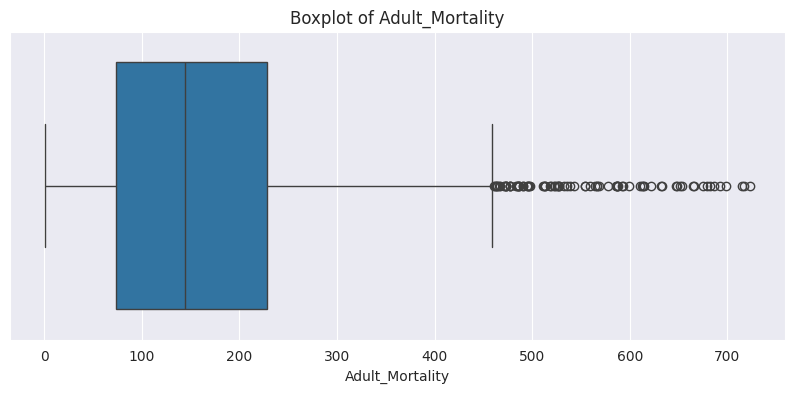

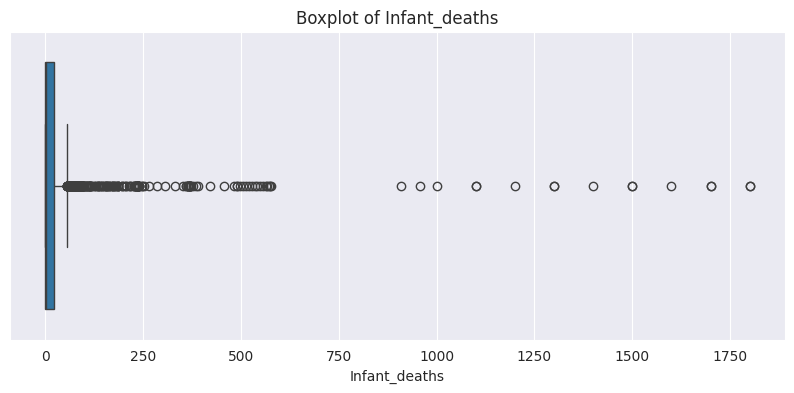

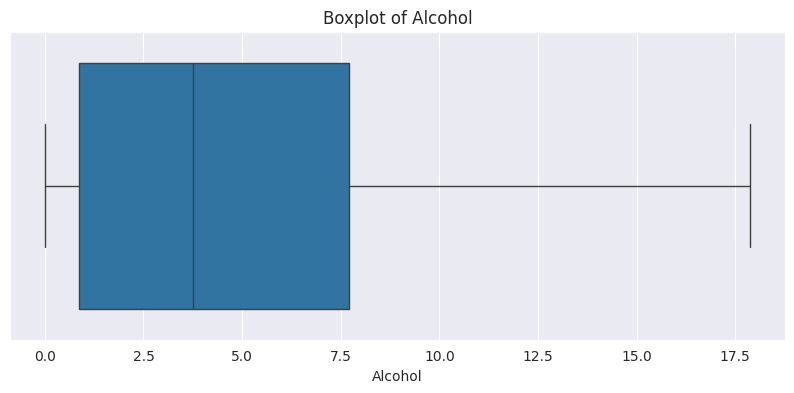

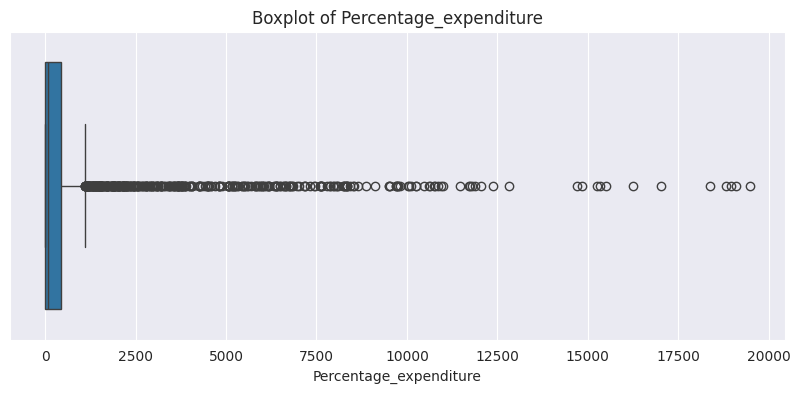

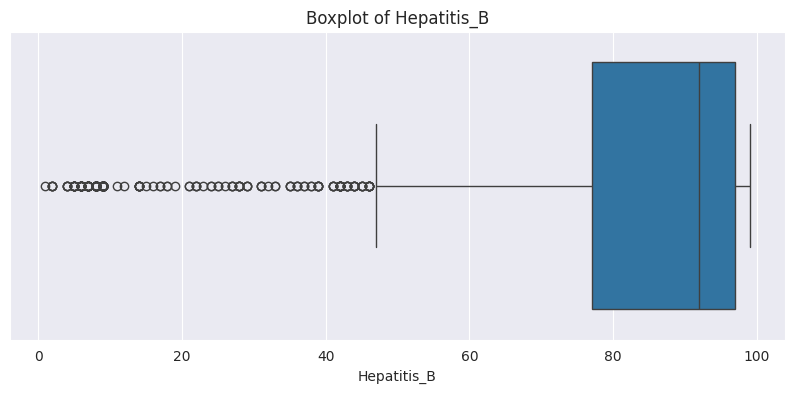

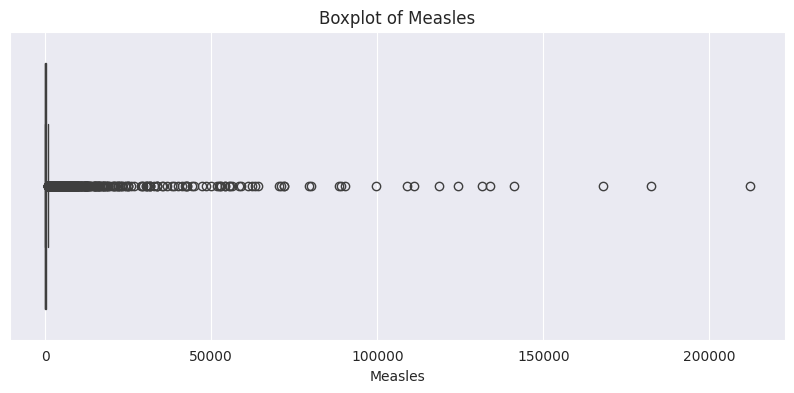

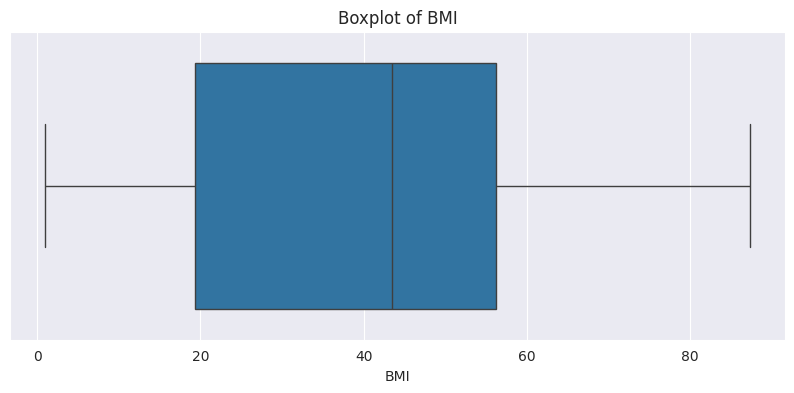

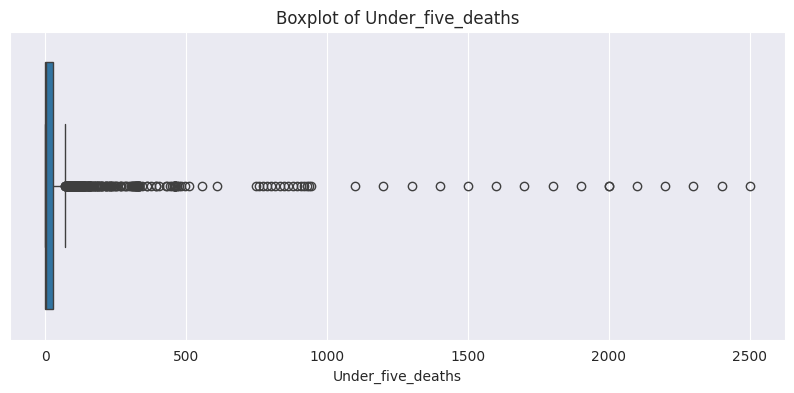

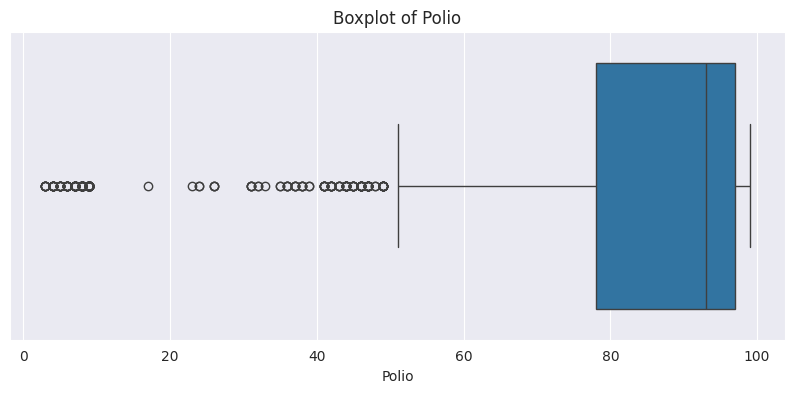

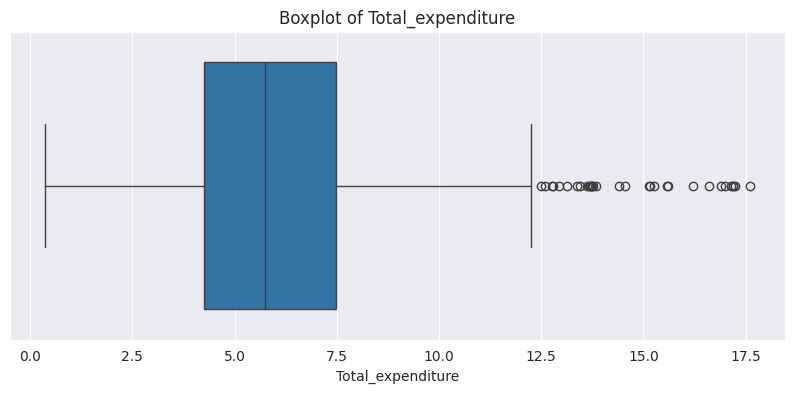

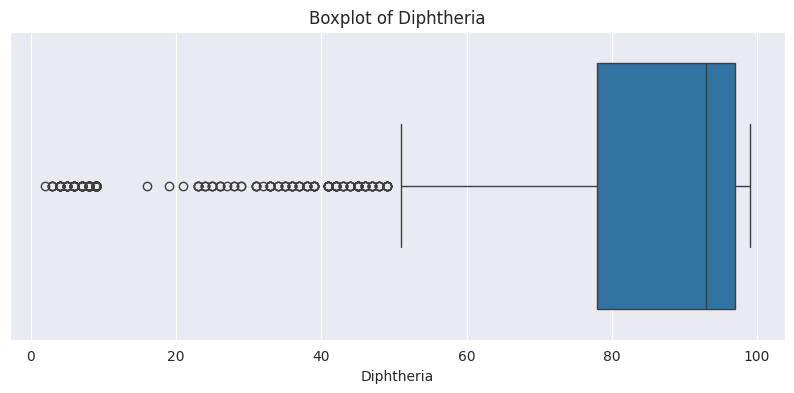

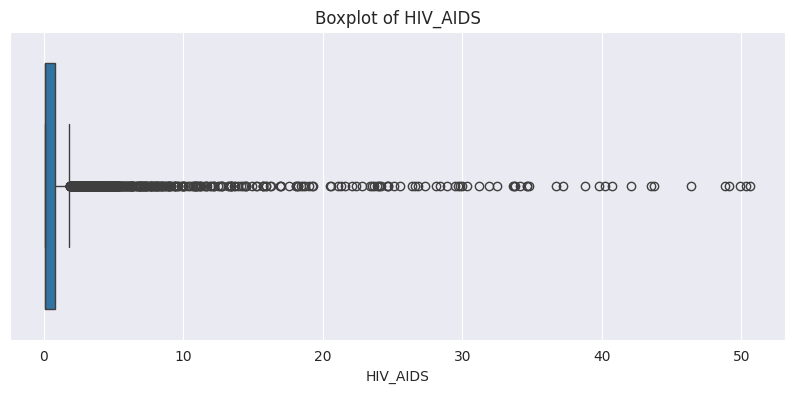

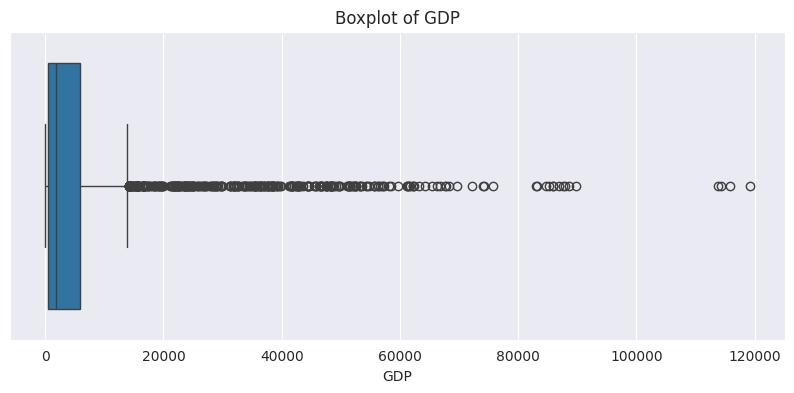

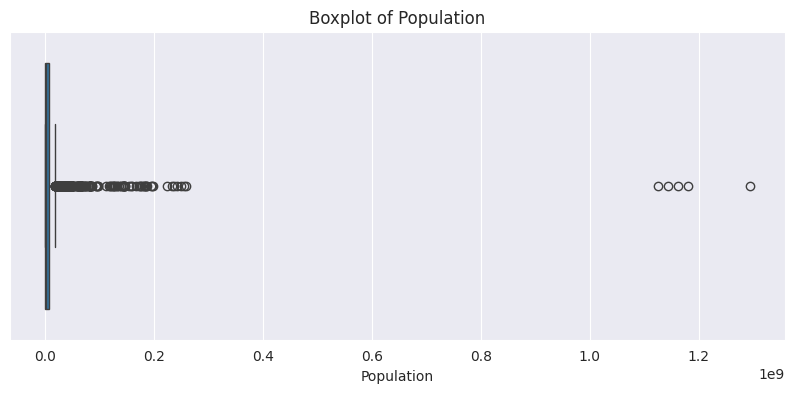

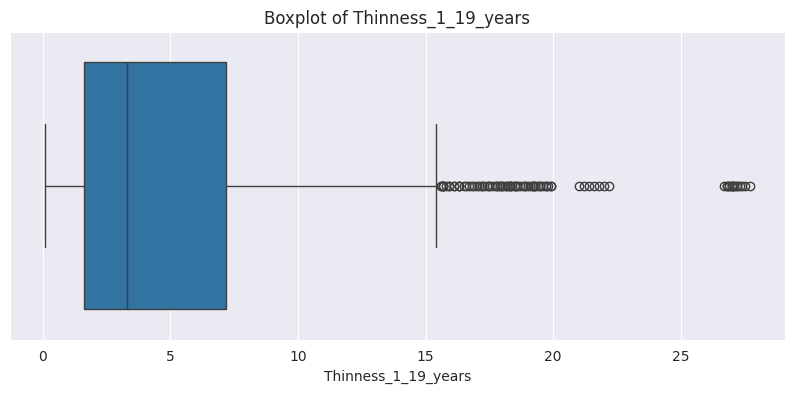

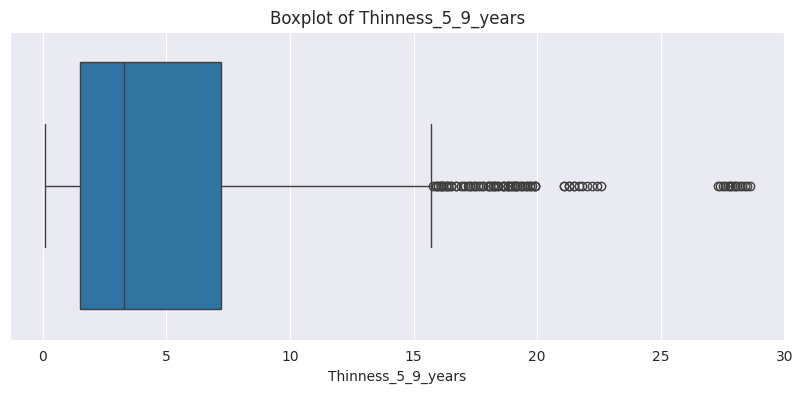

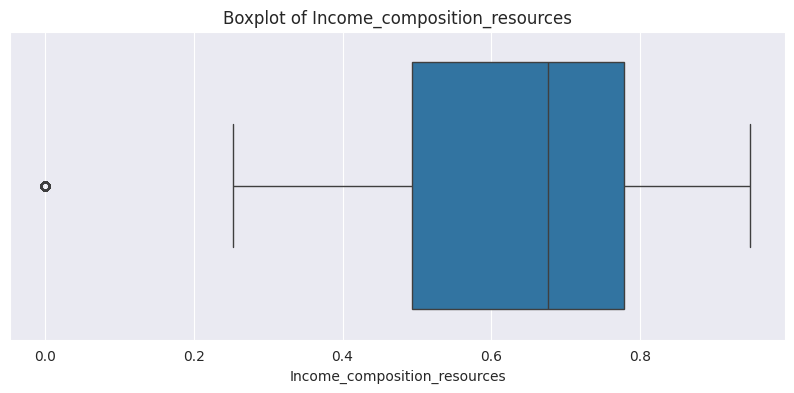

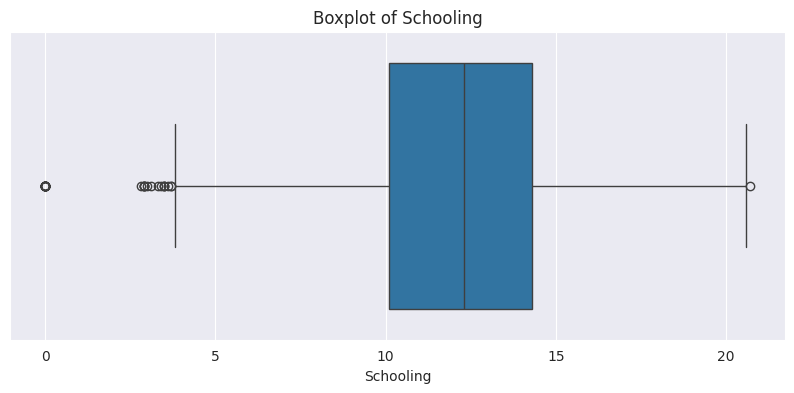

In [39]:
#plotting box plot to see outliers
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [40]:
#counting outliers
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)][col].count()
    outlier_counts[col] = count

for col, count in outlier_counts.items():
    print(f"{col}: {count} outliers")


Year: 0 outliers
Life_expectancy: 10 outliers
Adult_Mortality: 82 outliers
Infant_deaths: 315 outliers
Alcohol: 0 outliers
Percentage_expenditure: 389 outliers
Hepatitis_B: 254 outliers
Measles: 542 outliers
BMI: 0 outliers
Under_five_deaths: 394 outliers
Polio: 279 outliers
Total_expenditure: 32 outliers
Diphtheria: 298 outliers
HIV_AIDS: 542 outliers
GDP: 365 outliers
Population: 294 outliers
Thinness_1_19_years: 89 outliers
Thinness_5_9_years: 96 outliers
Income_composition_resources: 130 outliers
Schooling: 44 outliers


In [55]:
#filling missing values with mode
df_object = df.select_dtypes(include=['object']).columns

for col in df_object:
    mode_value = df[col].mode()[0]
    df[col].fillna(mode_value, inplace=True)

/tmp/ipykernel_60863/1248043839.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [56]:
# Check if any object column still has missing values
for col in df_object:
    print(col, df[col].isnull().sum())

Country 0
Status 0


In [57]:
# Select numeric columns
df_numeric = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing values with median
for col in df_numeric:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

/tmp/ipykernel_60863/1581546585.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
/tmp/ipykernel_60863/1581546585.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [58]:
# Check if any numeric column still has missing values
for col in df_numeric:
    print(col, df[col].isnull().sum())

Year 0
Life_expectancy 0
Adult_Mortality 0
Infant_deaths 0
Alcohol 0
Percentage_expenditure 0
Hepatitis_B 0
Measles 0
BMI 0
Under_five_deaths 0
Polio 0
Total_expenditure 0
Diphtheria 0
HIV_AIDS 0
GDP 0
Population 0
Thinness_1_19_years 0
Thinness_5_9_years 0
Income_composition_resources 0
Schooling 0
